In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

In [2]:
filename = "C:/Users/pumam/OneDrive - UC San Diego/Desktop/SLEAP/labels.v001-cs-01.000_cs-1-trial 0.analysis.h5"


In [3]:
with h5py.File(filename, "r") as f:
    dset_names = list(f.keys())
    locations = f["tracks"][:].T
    node_names = [n.decode() for n in f["node_names"][:]]

print("===filename===")
print(filename)
print()

print("===HDF5 datasets===")
print(dset_names)
print()

print("===locations data shape===")
print(locations.shape)
print()

print("===nodes===")
for i, name in enumerate(node_names):
    print(f"{i}: {name}")
print()

===filename===
C:/Users/pumam/OneDrive - UC San Diego/Desktop/SLEAP/labels.v001-cs-01.000_cs-1-trial 0.analysis.h5

===HDF5 datasets===
['edge_inds', 'edge_names', 'instance_scores', 'labels_path', 'node_names', 'point_scores', 'provenance', 'track_names', 'track_occupancy', 'tracking_scores', 'tracks', 'video_ind', 'video_path']

===locations data shape===
(196, 9, 2, 1)

===nodes===
0: head
1: thorax
2: belly
3: LF
4: RF
5: LM
6: RM
7: LR
8: RR



In [4]:
frame_count, node_count, _, instance_count = locations.shape

print("frame count:", frame_count)
print("node count:", node_count)
print("instance count:", instance_count)

frame count: 196
node count: 9
instance count: 1


In [5]:
from scipy.interpolate import interp1d

def fill_missing(Y, kind="linear"):
    """Fills missing values independently along each dimension after the first."""

    # Store initial shape.
    initial_shape = Y.shape

    # Flatten after first dim.
    Y = Y.reshape((initial_shape[0], -1))

    # Interpolate along each slice.
    for i in range(Y.shape[-1]):
        y = Y[:, i]

        # Build interpolant.
        x = np.flatnonzero(~np.isnan(y))
        f = interp1d(x, y[x], kind=kind, fill_value=np.nan, bounds_error=False)

        # Fill missing
        xq = np.flatnonzero(np.isnan(y))
        y[xq] = f(xq)
        
        # Fill leading or trailing NaNs with the nearest non-NaN values
        mask = np.isnan(y)
        y[mask] = np.interp(np.flatnonzero(mask), np.flatnonzero(~mask), y[~mask])

        # Save slice
        Y[:, i] = y

    # Restore to initial shape.
    Y = Y.reshape(initial_shape)

    return Y

In [6]:
locations = fill_missing(locations)

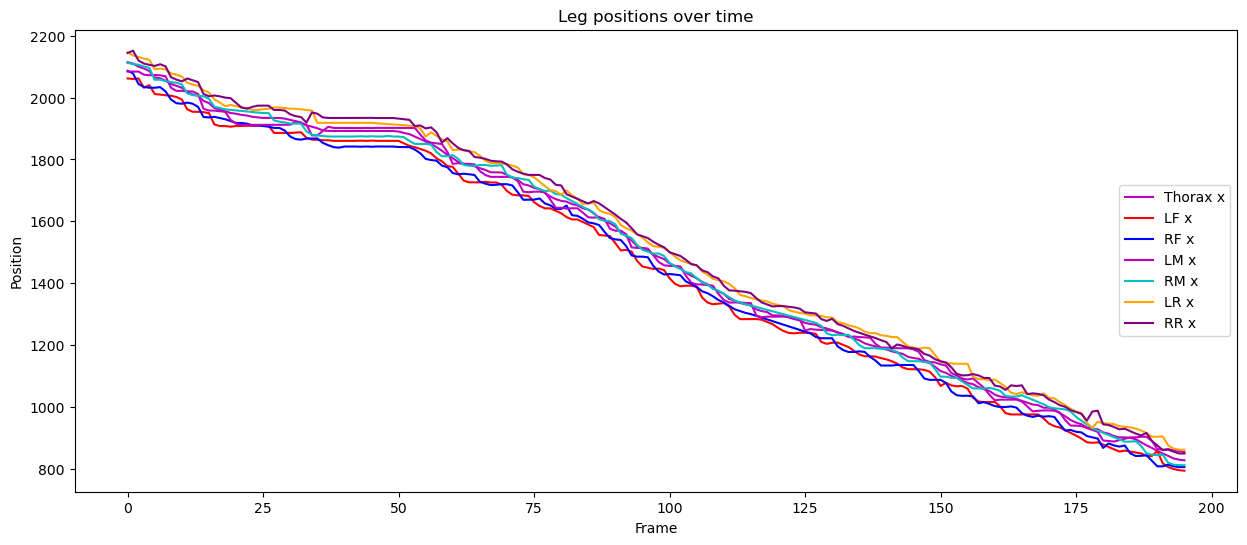

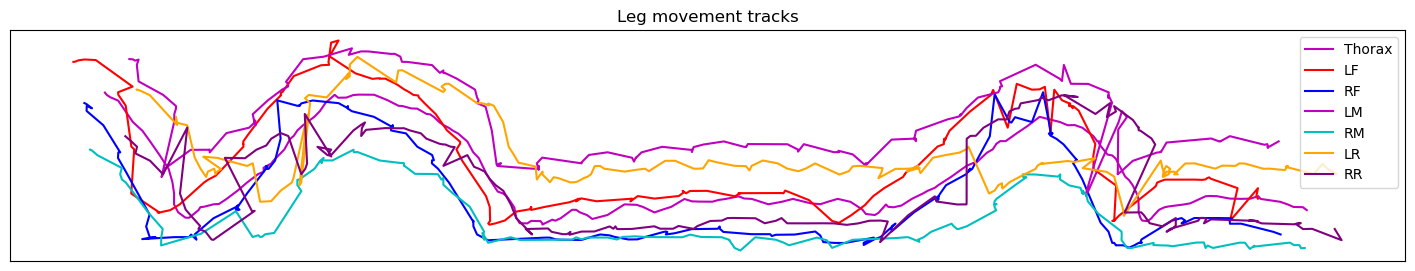

In [7]:
# Define indices for legs
Thorax_INDEX = 1
LF_INDEX = 3
RF_INDEX = 4
LM_INDEX = 5
RM_INDEX = 6
LR_INDEX = 7
RR_INDEX = 8

# Extract locations for each leg (single fly)
Thorax_loc = locations[:, Thorax_INDEX, :, 0] # thorax
lf_loc = locations[:, LF_INDEX, :, 0]  # Left Front
rf_loc = locations[:, RF_INDEX, :, 0]  # Right Front
lm_loc = locations[:, LM_INDEX, :, 0]  # Left Middle
rm_loc = locations[:, RM_INDEX, :, 0]  # Right Middle
lr_loc = locations[:, LR_INDEX, :, 0]  # Left Rear
rr_loc = locations[:, RR_INDEX, :, 0]  # Right Rear

# Define colors and labels for each leg
colors = ['m','r', 'b', 'm', 'c', 'orange', 'purple']
labels = ['Thorax','LF', 'RF', 'LM', 'RM', 'LR', 'RR']
leg_locs = [Thorax_loc, lf_loc, rf_loc, lm_loc, rm_loc, lr_loc, rr_loc]

# Plot movement over time
plt.figure(figsize=(15, 6))
for i, (leg, color, label) in enumerate(zip(leg_locs, colors, labels)):
    plt.plot(leg[:, 0], color, label=f'{label} x')  # X-axis
    #plt.plot(-1 * leg[:, 1], color, linestyle='dashed')  # Y-axis (negated for consistency)

plt.legend(loc="center right")
plt.title("Leg positions over time")
plt.xlabel("Frame")
plt.ylabel("Position")
#plt.savefig("legs poistions over time.pdf")

# Plot movement trajectories in 2D space
plt.figure(figsize=(18, 3))
for leg, color, label in zip(leg_locs, colors, labels):
    plt.plot(leg[:, 0], leg[:, 1], color, label=label)

plt.legend()
#plt.xlim(0, 1024)
plt.xticks([])
#plt.ylim(0, 1024)
plt.yticks([])
plt.title("Leg movement tracks")
#plt.savefig("two-legs track.pdf")
plt.show()


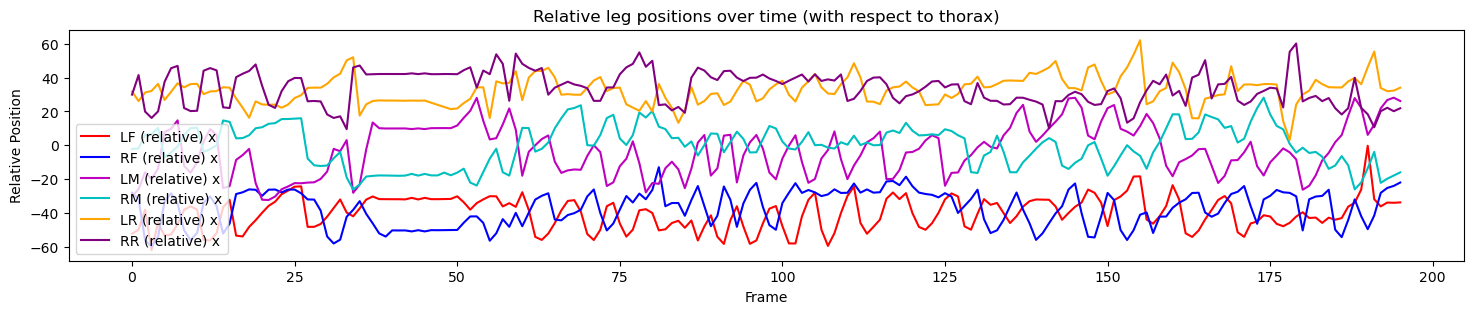

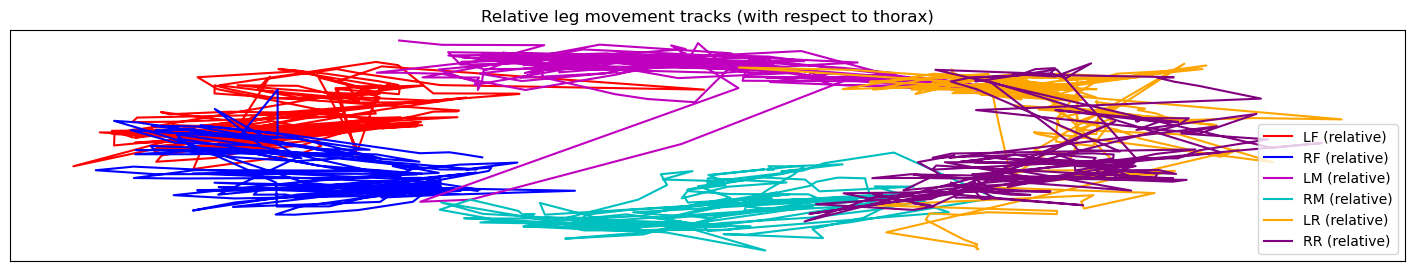

In [8]:
# Calculate relative positions of the legs with respect to the thorax
lf_relative = lf_loc - Thorax_loc
rf_relative = rf_loc - Thorax_loc
lm_relative = lm_loc - Thorax_loc
rm_relative = rm_loc - Thorax_loc
lr_relative = lr_loc - Thorax_loc
rr_relative = rr_loc - Thorax_loc
# Define colors and labels for each leg
colors = ['r', 'b', 'm', 'c', 'orange', 'purple']
labels = ['LF (relative)', 'RF (relative)', 'LM (relative)', 'RM (relative)', 'LR (relative)', 'RR (relative)']
relative_leg_locs = [lf_relative, rf_relative, lm_relative, rm_relative, lr_relative, rr_relative]

# Plot relative movement over time
plt.figure(figsize=(18, 3))
for i, (leg, color, label) in enumerate(zip(relative_leg_locs, colors, labels)):
    plt.plot(leg[:, 0], color, label=f'{label} x')  # X-axis
    #plt.plot(-1 * leg[:, 1], color, linestyle='dashed')  # Y-axis (negated for consistency)

plt.legend(loc="lower left")
plt.title("Relative leg positions over time (with respect to thorax)")
plt.xlabel("Frame")
plt.ylabel("Relative Position")
#plt.savefig("relative_legs_positions_over_time.pdf")

## Plot relative movement trajectories in 2D space
plt.figure(figsize=(18, 3))
for leg, color, label in zip(relative_leg_locs, colors, labels):
    plt.plot(leg[:, 0], leg[:,1], color, label=label)

plt.legend()
#plt.xlim(0, 1024)
plt.xticks([])
#plt.ylim(0, 1024)
plt.yticks([])
plt.title("Relative leg movement tracks (with respect to thorax)")
#plt.savefig("relative_two_legs_track.pdf")
plt.show()

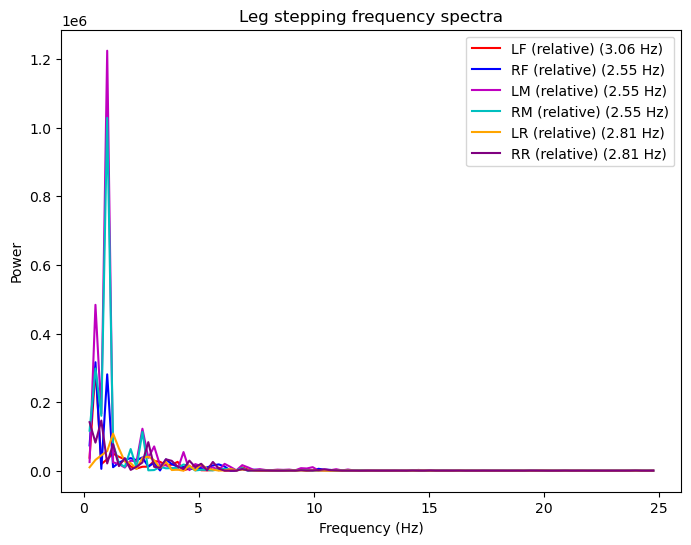

Dominant stepping frequencies:
LF (relative): 3.06 Hz
RF (relative): 2.55 Hz
LM (relative): 2.55 Hz
RM (relative): 2.55 Hz
LR (relative): 2.81 Hz
RR (relative): 2.81 Hz


In [9]:
from scipy.signal import find_peaks, savgol_filter
from scipy.signal import detrend
fs = 50
legs = [lf_relative, rf_relative, lm_relative, rm_relative, lr_relative, rr_relative]
plt.figure(figsize=(8,6))

dominant_freqs = []

for leg, label, color in zip(legs, labels, colors):

    # --- extract forward/backward displacement ---
    signal = leg[:,0]

    # --- remove mean ---
    signal = detrend(leg[:,0])

    # --- smooth signal (reduce tracking noise) ---
    signal = savgol_filter(signal, 11, 3)

    # --- FFT ---
    N = len(signal)
    fft_vals = np.fft.fft(signal)
    freqs = np.fft.fftfreq(N, d=1/fs)

    power = np.abs(fft_vals)**2

    # only positive frequencies
    mask = freqs > 0
    freqs = freqs[mask]
    power = power[mask]

     # only search biologically realistic stepping range
    valid = (freqs > 2) & (freqs < 12)
    freqs_valid = freqs[valid]
    power_valid = power[valid]

    # find peak frequency
    peak_idx = np.argmax(power_valid)
    dominant_freq = freqs_valid[peak_idx]

    dominant_freqs.append(dominant_freq)

    # --- plot spectrum ---
    plt.plot(freqs, power, color=color, label=f"{label} ({dominant_freq:.2f} Hz)")

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.title("Leg stepping frequency spectra")
plt.legend()
plt.show()

print("Dominant stepping frequencies:")
for label, f in zip(labels, dominant_freqs):
    print(f"{label}: {f:.2f} Hz")

Mean phase difference (LF vs RF): -0.5623150686543774


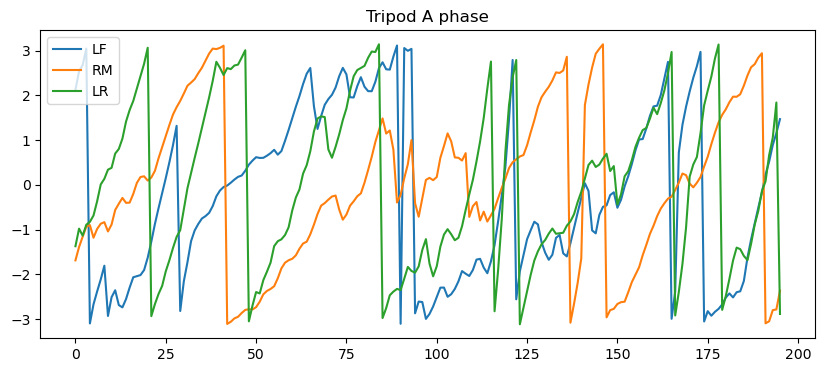

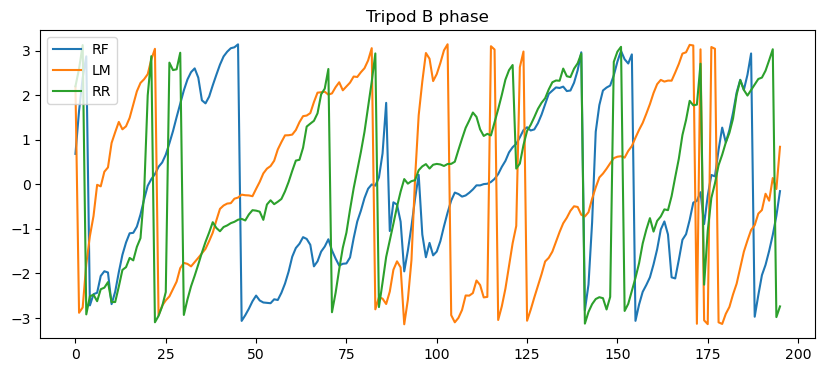

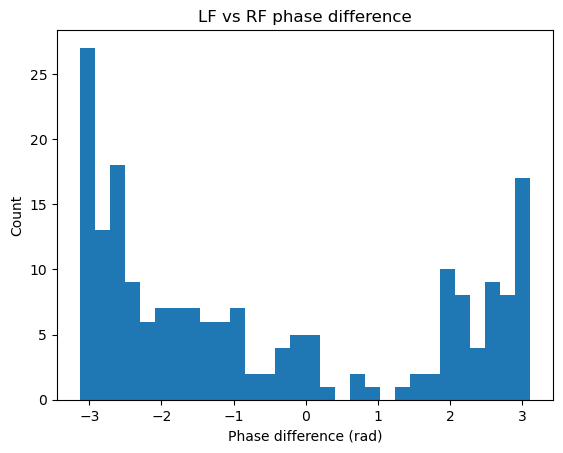

In [10]:
from scipy.signal import hilbert
import numpy as np
labels = ['LF', 'RF', 'LM', 'RM', 'LR', 'RR']
signals = {}

for leg, label in zip(legs, labels):

    signal = leg[:,0]

    signal = detrend(signal)
    signal = savgol_filter(signal, 11, 3)

    signals[label] = signal

phases = {}

for label in signals:

    analytic_signal = hilbert(signals[label])
    phase = np.angle(analytic_signal)

    phases[label] = phase

phase_diff_LF_RF = np.angle(np.exp(1j*(phases['LF'] - phases['RF'])))

mean_phase = np.mean(phase_diff_LF_RF)

print("Mean phase difference (LF vs RF):", mean_phase)

plt.figure(figsize=(10,4))

plt.plot(phases['LF'], label='LF')
plt.plot(phases['RM'], label='RM')
plt.plot(phases['LR'], label='LR')

plt.legend()
plt.title("Tripod A phase")
plt.show()

plt.figure(figsize=(10,4))

plt.plot(phases['RF'], label='RF')
plt.plot(phases['LM'], label='LM')
plt.plot(phases['RR'], label='RR')

plt.legend()
plt.title("Tripod B phase")
plt.show()

plt.hist(phase_diff_LF_RF, bins=30)
plt.xlabel("Phase difference (rad)")
plt.ylabel("Count")
plt.title("LF vs RF phase difference")
plt.show()

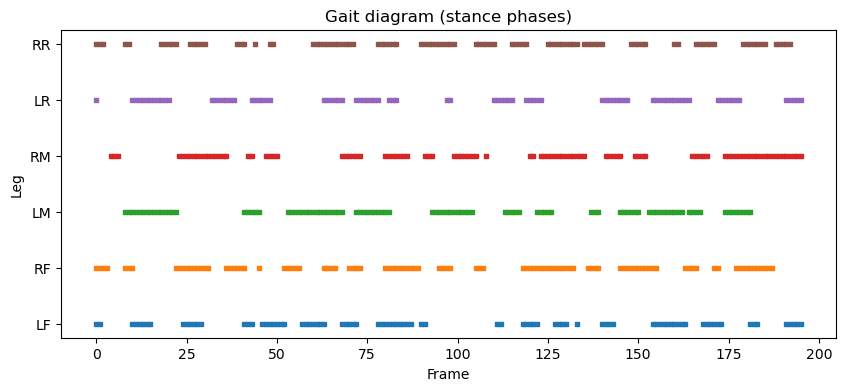

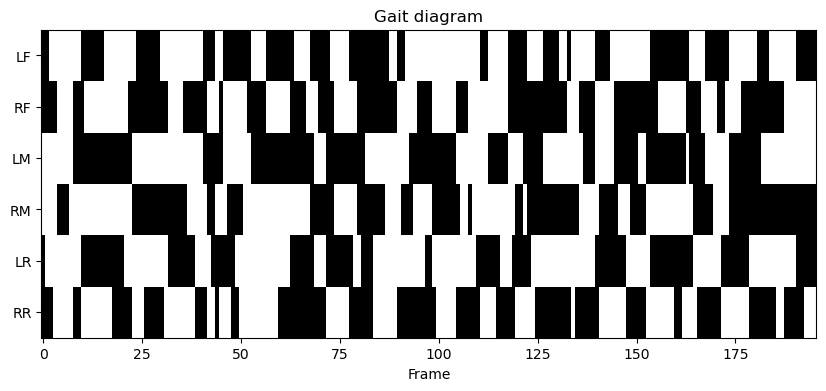

In [11]:
stance_binary = []

for leg in legs:

    signal = leg[:,0]

    signal = detrend(signal)
    signal = savgol_filter(signal, 11, 3)

    #velocity = np.gradient(signal)
    velocity = savgol_filter(np.gradient(signal), 9, 2)


    # stance = moving backward
    stance = velocity < 0

    stance_binary.append(stance)

plt.figure(figsize=(10,4))

for i, stance in enumerate(stance_binary):

    y = np.ones(len(stance)) * i

    plt.scatter(np.where(stance)[0], y[stance],
                marker='s', s=10)

plt.yticks(range(6), labels)
plt.xlabel("Frame")
plt.ylabel("Leg")
plt.title("Gait diagram (stance phases)")
plt.show()

gait_matrix = np.array(stance_binary)

plt.figure(figsize=(10,4))
plt.imshow(gait_matrix, aspect='auto', cmap='gray_r')

plt.yticks(range(6), labels)
plt.xlabel("Frame")
plt.title("Gait diagram")
plt.show()

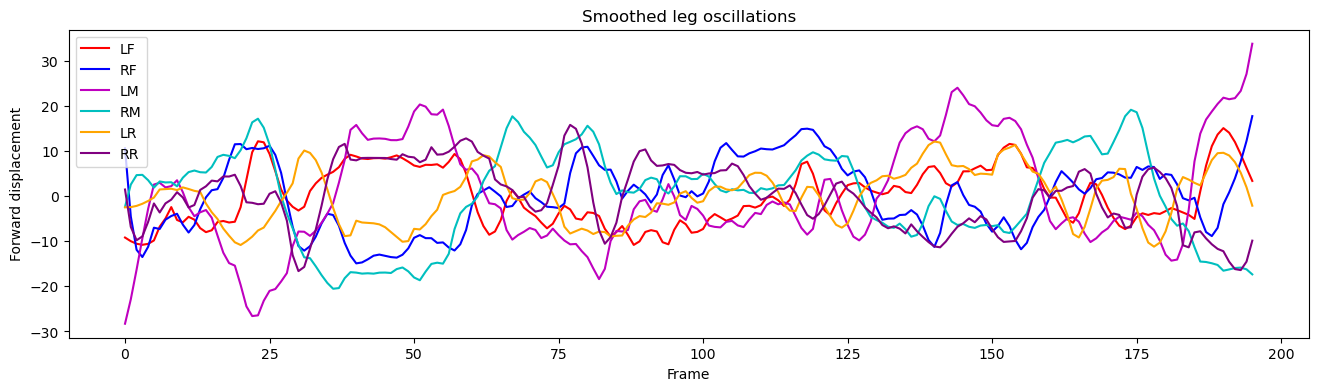

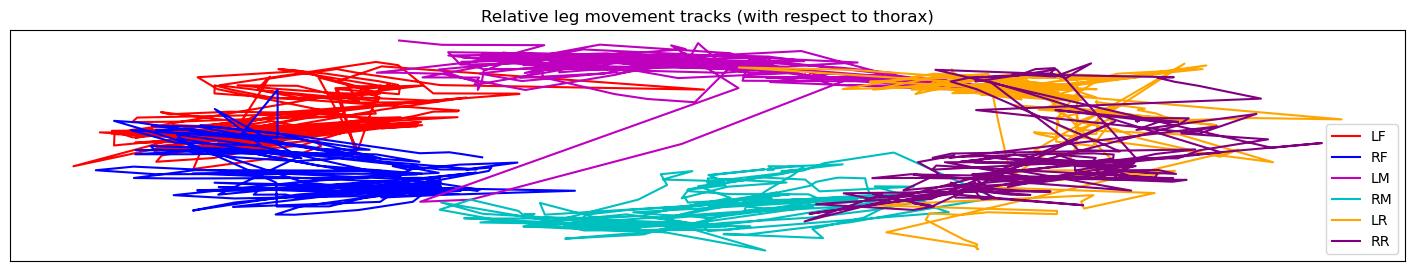

In [12]:
plt.figure(figsize=(16,4))

for leg, label, color in zip(legs, labels, colors):

    signal = leg[:,0]
    signal = signal - np.mean(signal)
    signal = savgol_filter(signal, 11, 3)

    plt.plot(signal, color=color, label=label)

plt.xlabel("Frame")
plt.ylabel("Forward displacement")
plt.title("Smoothed leg oscillations")
plt.legend()
plt.show()

## Plot relative movement trajectories in 2D space
plt.figure(figsize=(18, 3))
for leg, color, label in zip(relative_leg_locs, colors, labels):
    plt.plot(leg[:, 0], leg[:,1], color, label=label)

plt.legend()
#plt.xlim(0, 1024)
plt.xticks([])
#plt.ylim(0, 1024)
plt.yticks([])
plt.title("Relative leg movement tracks (with respect to thorax)")
#plt.savefig("relative_two_legs_track.pdf")
plt.show()

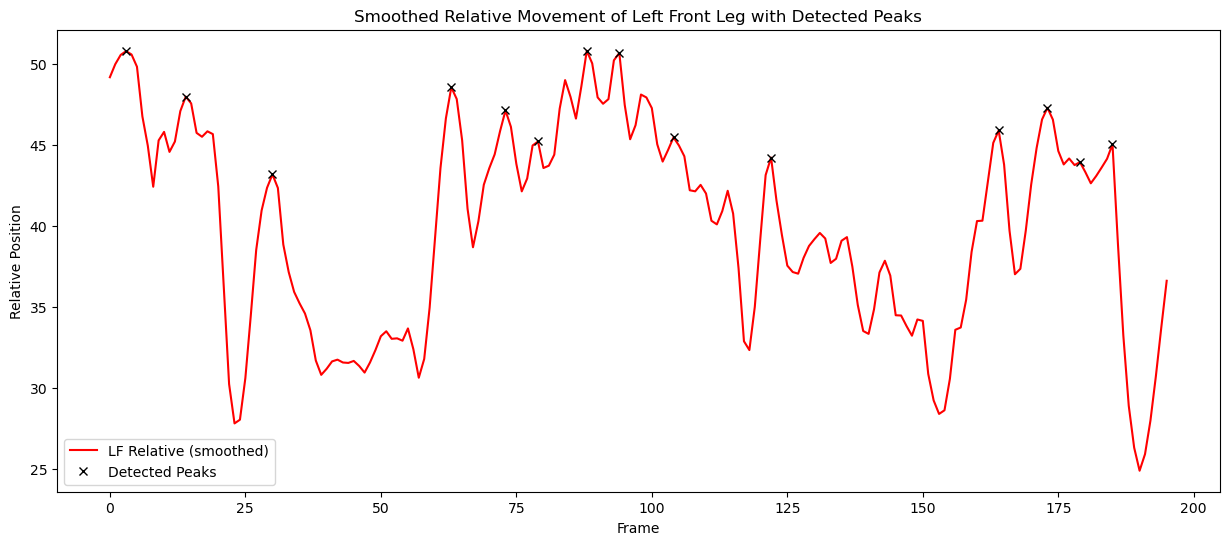

Number of steps detected: 14


In [13]:
from scipy.signal import find_peaks, savgol_filter

# Smooth the relative movement signal of the Left Front leg
lf_relative_smoothed = savgol_filter(lf_relative[:, 0], window_length=11, polyorder=3)  # Adjust window_length and polyorder as needed
lf_abs = np.abs(lf_relative_smoothed)
# Detect peaks in the smoothed signal
peaks, _ = find_peaks(lf_abs, height= np.percentile(lf_abs, 60), distance=5)  # Adjust height and distance thresholds as needed

# Plot the smoothed signal and detected peaks
plt.figure(figsize=(15, 6))
plt.plot(lf_abs, color='r', label='LF Relative (smoothed)')
plt.plot(peaks, lf_abs[peaks], 'x', color='black', label='Detected Peaks')
plt.legend(loc="lower left")
plt.title("Smoothed Relative Movement of Left Front Leg with Detected Peaks")
plt.xlabel("Frame")
plt.ylabel("Relative Position")
plt.show()

# Print the number of detected steps
print(f"Number of steps detected: {len(peaks)}")

In [32]:
# Store legs in dictionary for clarity
legs_dict = {
    'LF': lf_relative,
    'RF': rf_relative,
    'LM': lm_relative,
    'RM': rm_relative,
    'LR': lr_relative,
    'RR': rr_relative
}

peak_counts = {}
all_peaks = {}

# --- Step 1: detect peaks for each leg ---
for label, leg in legs_dict.items():

    # smooth signal
    signal = savgol_filter(leg[:, 0], 11, 3)

    # absolute value (like you did)
    signal_abs = np.abs(signal)

    # adaptive threshold
    threshold = np.percentile(signal_abs, 60)

    # detect peaks
    peaks, _ = find_peaks(signal_abs,
                          height=threshold,
                          distance=5)

    peak_counts[label] = len(peaks)
    all_peaks[label] = peaks

# --- Step 2: compute tripod averages ---
tripod_A = ['LF', 'RM', 'LR']
tripod_B = ['RF', 'LM', 'RR']

avg_A = np.mean([peak_counts[l] for l in tripod_A])
avg_B = np.mean([peak_counts[l] for l in tripod_B])

# final step estimate
estimated_steps = np.mean([avg_A, avg_B])

# --- Step 3: print results ---
print("Peak counts per leg:")
for k, v in peak_counts.items():
    print(f"{k}: {v}")

print("\nTripod averages:")
print(f"Tripod A (LF, RM, LR): {avg_A:.2f}")
print(f"Tripod B (RF, LM, RR): {avg_B:.2f}")

print(f"\nEstimated total steps: {estimated_steps:.2f}")

Peak counts per leg:
LF: 14
RF: 13
LM: 15
RM: 11
LR: 15
RR: 13

Tripod averages:
Tripod A (LF, RM, LR): 13.33
Tripod B (RF, LM, RR): 13.67

Estimated total steps: 13.50


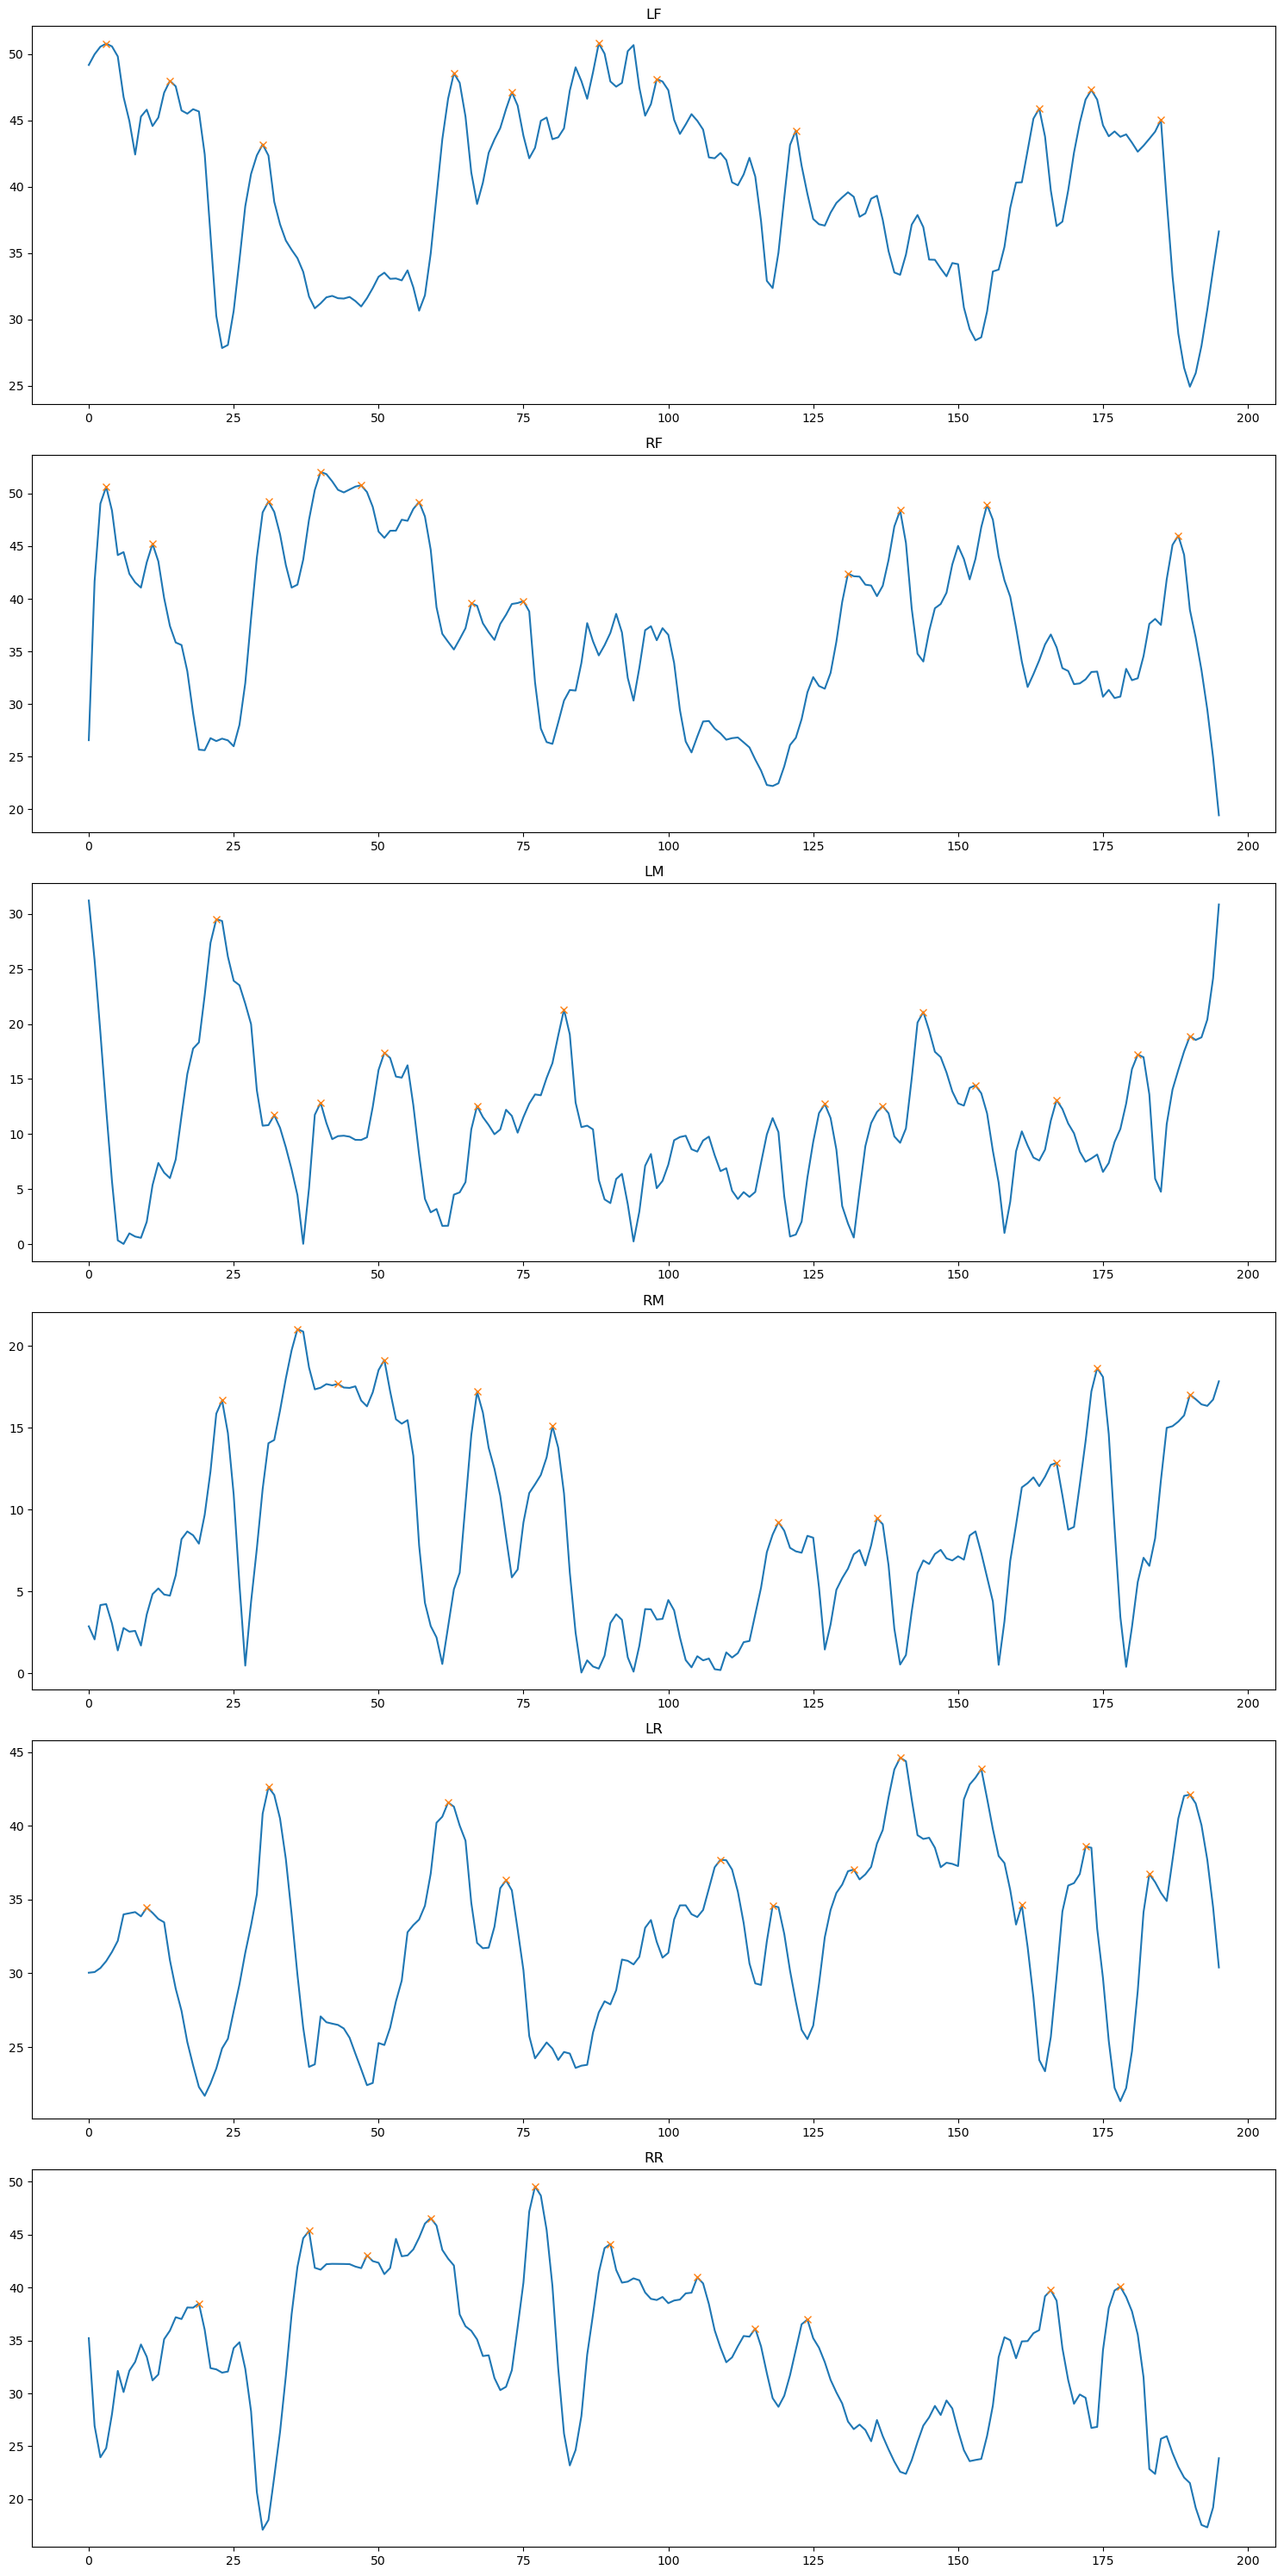

In [15]:
plt.figure(figsize=(15,30))

for i, (label, leg) in enumerate(legs_dict.items()):

    signal = savgol_filter(leg[:,0], 11, 3)
    signal_abs = np.abs(signal)
    peaks = all_peaks[label]

    plt.subplot(6,1,i+1)
    plt.plot(signal_abs)
    plt.plot(peaks, signal_abs[peaks], 'x')
    plt.title(label)

plt.tight_layout()
plt.show()